In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("../data/student_data.csv")
# tell us about the data types and non-null counts
# df.info() 

# mean, std, min, max, 25%, 50%, 75%
df.describe() 

# show the first 5 rows of the data
df.head()
# df.isnull().sum() // check for missing values in each column

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


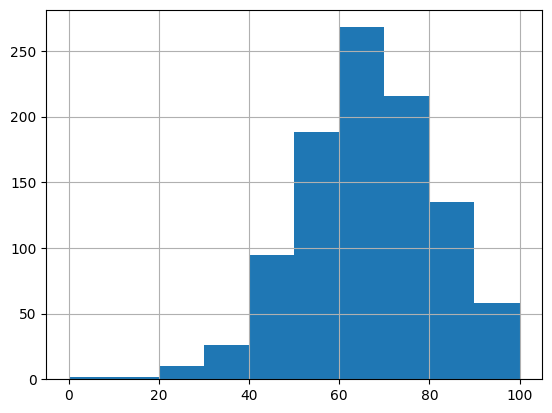

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("../data/student_data.csv")

df["gender"].value_counts()
df["parental level of education"].value_counts()
df.groupby("gender")[["math score"]].mean()
df["math score"].hist()
plt.show()

MAE: 4.214763142474851
MSE: 29.095169866715494
R2 Score: 0.8804332983749564


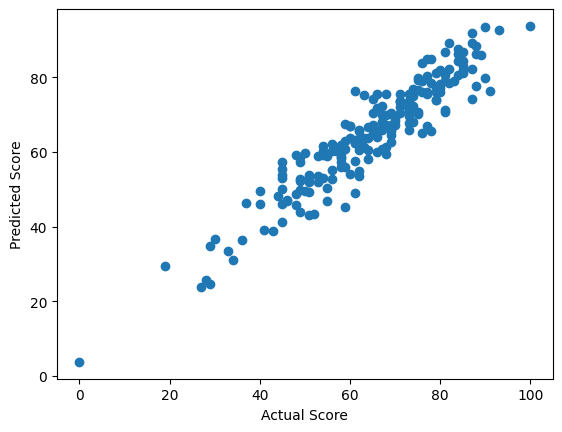

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../data/student_data.csv")

X = df.drop("math score", axis=1)
y = df["math score"]

# y.head()
X = pd.get_dummies(X, drop_first=True)
X.head()

# X.info()

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

X_train.shape
X_test.shape

from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train, y_train)

predictions = model.predict(X_test)
predictions[:10]

comparison = pd.DataFrame({
  "Actual": y_test, 
  "Predicted": predictions})

comparison.head(10)

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

mae = mean_absolute_error(y_test, predictions)
print("MAE:", mae)

mse = mean_squared_error(y_test, predictions)

print("MSE:", mse)

r2 = r2_score(y_test, predictions)

print("R2 Score:", r2)

plt.scatter(y_test, predictions)
plt.xlabel("Actual Score")
plt.ylabel("Predicted Score")
plt.show()

MAE: 11.269872775277623
MSE: 200.510845643673
R2 Score: 0.17599998338251166


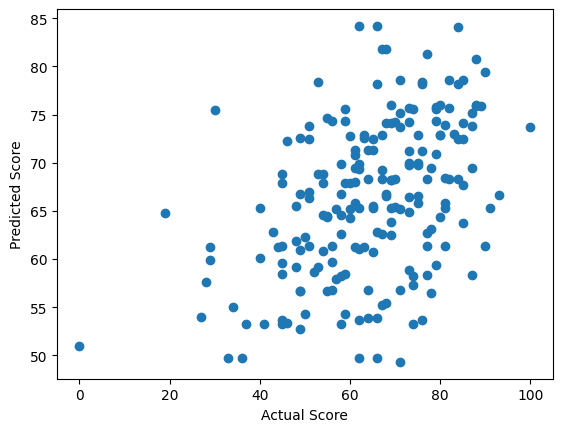

In [7]:
X = df.drop(["math score", "reading score", "writing score"], axis=1)
y = df["math score"]

X = pd.get_dummies(X, drop_first=True)
X.head()

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train, y_train)

predictions = model.predict(X_test)

mae = mean_absolute_error(y_test, predictions)
print("MAE:", mae)
mse = mean_squared_error(y_test, predictions)
print("MSE:", mse)
r2 = r2_score(y_test, predictions)
print("R2 Score:", r2)

plt.scatter(y_test, predictions)
plt.xlabel("Actual Score")
plt.ylabel("Predicted Score")
plt.show()

feature_importance = pd.DataFrame({
  "Feature": X.columns,
  "Coefficient": model.coef_      
})
feature_importance.sort_values(
  by="Coefficient", 
  ascending=False, 
  inplace=True
)


In [14]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(random_state=42)
}

results = {}

for name, model in models.items():
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    results[name] = {
        "MAE": mae,
        "MSE": mse,
        "R2": r2
    }

results

import pandas as pd

results_df = pd.DataFrame(results).T
results_df

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

feature_importance



,Feature,Importance
10,lunch_standard,0.251901
11,test preparation course_none,0.101874
0,gender_male,0.099604
4,race/ethnicity_group E,0.091060
6,parental level of education_high school,0.063694
2,race/ethnicity_group C,0.061813
1,race/ethnicity_group B,0.061485
5,parental level of education_bachelor's degree,0.061051
8,parental level of education_some college,0.059691
9,parental level of education_some high school,0.057304


In [20]:
from sklearn.linear_model import LinearRegression
best_model = LinearRegression()
best_model.fit(X_train, y_train)

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': best_model.coef_
}).sort_values(by='Coefficient', ascending=False)
feature_importance

# import matplotlib.pyplot as plt
# plt.figure(figsize=(10, 6))
# plt.barh(feature_importance['Feature'], feature_importance['Coefficient'])
# plt.xlabel('Coefficient Value')
# plt.ylabel('Feature')
# plt.title('Feature Influence on Student Score')

# plt.show()

,Feature,Coefficient
10,lunch_standard,11.523997
4,race/ethnicity_group E,9.077935
0,gender_male,4.520714
3,race/ethnicity_group D,3.612132
5,parental level of education_bachelor's degree,3.119051
7,parental level of education_master's degree,1.074605
2,race/ethnicity_group C,0.602873
1,race/ethnicity_group B,0.182362
8,parental level of education_some college,-0.145008
9,parental level of education_some high school,-2.896392


In [21]:
import os
import joblib
os.makedirs("../models", exist_ok=True)

joblib.dump(
    best_model,
    "../models/student_score_predictor.pkl"
)

['../models/student_score_predictor.pkl']

In [23]:
loaded_model = joblib.load("../models/student_score_predictor.pkl")
loaded_model.predict(X_test[:5])

array([65.34427246, 59.12926988, 75.99329632, 58.19598252, 84.06955378])